### George Boufis f3352504
## Data Science Challenge

### Publication Venue Prediction

## Goal
The goal of this project is to predict the publication venue of scientific papers using multiple sources of information:

- Paper abstracts
- Authors
- Publication years
- Citation / graph structure from the edgelist

We combine textual, temporal, author-based, and graph-based features in order to capture as much predictive signal as possible.

## Overall Pipeline:

The pipeline consists of:
1. Loading and preprocessing the data
2. Feature extraction from:
     - abstracts
     - authors
     - years
     - graph structure
3. Feature combination
4. Model Training
5. Validation and evaluation
6. Submission generation

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/giorgosboufis/scibert-outputs/val_probs_scibert.npy
/kaggle/input/datasets/giorgosboufis/scibert-outputs/test_probs_scibert.npy
/kaggle/input/datasets/giorgosboufis/scibert-embeddings/X_val_scibert.npy
/kaggle/input/datasets/giorgosboufis/scibert-embeddings/X_test_scibert.npy
/kaggle/input/datasets/giorgosboufis/scibert-embeddings/X_train_scibert.npy
/kaggle/input/datasets/giorgosboufis/trained-lora-model/adapter_model.safetensors
/kaggle/input/datasets/giorgosboufis/trained-lora-model/training_args.bin
/kaggle/input/datasets/giorgosboufis/trained-lora-model/adapter_config.json
/kaggle/input/datasets/giorgosboufis/trained-lora-model/README.md
/kaggle/input/datasets/giorgosboufis/trained-lora-model/tokenizer.json
/kaggle/input/datasets/giorgosboufis/trained-lora-model/tokenizer_config.json
/kaggle/input/datasets/giorgosboufis/publication-venue-prediction-challenge/abstracts.txt
/kaggle/input/datasets/giorgosboufis/publication-venue-prediction-challenge/edgelist.tx

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, log_loss

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model, TaskType

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Loading and Preparing the Core Datasets

In this section we load the main datasets used in the publication venue prediction task.

The available data sources provide complementary information:
- abstracts.txt -> semantic/content information from paper abstracts
- years.txt -> temporal information about publication year
- y_train.txt -> training labels (target venues)
- y_test.txt -> test paper IDs for final prediction


## Custom file loader

The abstracts file uses the format:

id || abstract_text

We therefore create a custom loading function (`load_pipe_file`) to: 
- correclty split each row
- separate paper IDs from text
- convert IDs into integers
- store the result in a pandas DataFrame

This makes preprocessing cleaner and reusable for similar files.

Before feature engineering and model training, we must:
- load the data into structured tables,
- clean the formatting,
- ensure consistent data types,
- align all datasets using the paper `id`.


The `id` column is especially important because it allows us to merge abstracts, years, authors, graph features and labels into a unified feature representation for each paper.

In [3]:
base_path = "/kaggle/input/datasets/giorgosboufis/publication-venue-prediction-challenge/"

def load_pipe_file(filename, col_name):
    data = []
    path = os.path.join(base_path, filename)
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("||", 1)
            if len(parts) == 2:
                data.append(parts)
    df = pd.DataFrame(data, columns=["id", col_name])
    df["id"] = df["id"].astype(int)
    return df

print("Loading abstracts, labels, years and test IDs...")

df_abstracts = load_pipe_file("abstracts.txt", "abstract")

df_years = pd.read_csv(
    os.path.join(base_path, "years.txt"),
    sep=",",
    header=None,
    names=["id", "year"]
)
df_years["id"] = df_years["id"].astype(int)
df_years["year"] = df_years["year"].astype(int)

df_train = pd.read_csv(
    os.path.join(base_path, "y_train.txt"),
    sep=",",
    header=None,
    names=["id", "label"]
)
df_train["id"] = df_train["id"].astype(int)
df_train["label"] = df_train["label"].astype(int)

df_test = pd.read_csv(
    os.path.join(base_path, "y_test.txt"),
    sep=",",
    header=None,
    usecols=[0],
    names=["id"]
)
df_test["id"] = df_test["id"].astype(int)

print("Abstracts:", df_abstracts.shape)
print("Years:", df_years.shape)
print("Train labels:", df_train.shape)
print("Test IDs:", df_test.shape)

Loading abstracts, labels, years and test IDs...
Abstracts: (217936, 2)
Years: (217936, 2)
Train labels: (174286, 2)
Test IDs: (43650, 1)


In this step we combine the different data sources into unified datasets for training and prediction. We merge abstracts, publication years and labels using the common paper `id`.

Each file contains only part of the information for a paper.

By merging them together, we create a complete representation of each paper that can later be transformed into machine learning features.

The final training table containts:
1. paper ID
2. publication venue label
3. abstract text
4. publication year

The test table contains the same information except for the labels, which are the values we want to predict.

## Handling Missing Values

Some papers may:
- have missing abstracts,
- have missing year information.

Machine Learning pipelines usually cannot handle missing values directly, so we replace them with safe defaults:
- Missing abstracts -> empty string ""
- Missing years -> `0`
This ensures consistent preprocessing, stable feature extraction and no runtime errors during training.

Before continuing, we check how many missing values exist and the final shapes of the train and test datasets.

In [4]:
# Build train/test dataframes

train_data = df_train.copy()
train_data = train_data.merge(df_abstracts, on="id", how="left")
train_data = train_data.merge(df_years, on="id", how="left")

test_data = df_test.copy()
test_data = test_data.merge(df_abstracts, on="id", how="left")
test_data = test_data.merge(df_years, on="id", how="left")

# Check missing values before filling
print("Missing abstracts train:", train_data["abstract"].isna().sum())
print("Missing years train:", train_data["year"].isna().sum())
print("Missing abstracts test:", test_data["abstract"].isna().sum())
print("Missing years test:", test_data["year"].isna().sum())

# Fill missing values
train_data["abstract"] = train_data["abstract"].fillna("")
test_data["abstract"] = test_data["abstract"].fillna("")

train_data["year"] = train_data["year"].fillna(0).astype(int)
test_data["year"] = test_data["year"].fillna(0).astype(int)

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

train_data.head()

Missing abstracts train: 0
Missing years train: 0
Missing abstracts test: 0
Missing years test: 0
Train shape: (174286, 4)
Test shape: (43650, 3)


,id,label,abstract,year
0,0,0,In this paper we study the problems of detecti...,2007
1,1,0,In this paper we consider the problem of compu...,2004
2,3,1,This paper presents an efficient framework for...,2005
3,4,1,In traditional approaches for clustering marke...,2004
4,5,2,A quality-time analysis of multi-objective evo...,2005


### Train / Validation Split

Before training the model, we split the available labeled data into:
- Training set,
- Validation set
The training set is used to learn the model parameters, while the validation set is used to evaluate how well the model generalizes to unseen data.

We need the Validation Set, because evaluating the model only on the training data is misleading because the model has already seen those examples.

Validation set helps us:
- estimate real-word performance
- detect overfitting,
- compare different models and hyperparameters fairly.



In [5]:
# Train / Validation split
df_train_final, df_val_final = train_test_split(
    train_data,
    test_size=0.2,
    random_state=SEED,
    stratify=train_data["label"]
)

# Reset indices (important later for embeddings/alignment)
df_train_final = df_train_final.reset_index(drop=True)
df_val_final = df_val_final.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

# Basic info
num_labels = train_data["label"].nunique()

print("Training samples:", len(df_train_final))
print("Validation samples:", len(df_val_final))
print("Number of labels:", num_labels)
print("Labels:", sorted(train_data["label"].unique()))

Training samples: 139428
Validation samples: 34858
Number of labels: 7
Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In this step we extract the target labels for:
1. the training set,
2. the validation set

The labels are extracted after the train / validation split to ensure that feature rows, embeddings, graph representations and labels all remain perfectly aligned.

In [6]:
# Labels aligned with the fixed train/validation split
y_train = df_train_final["label"].values
y_val = df_val_final["label"].values

print(y_train.shape, y_val.shape)

(139428,) (34858,)


### Class Distribution Analysis

Figure X illustrates the distribution of publication venues across the seven target classes. The dataset exhibits a moderate class imbalance, with class 5 being the most frequent category and classes 0 and 1 being the least represented. The distribution remains relatively balanced compared to many real-world multiclass classification problems, as no class dominates the dataset excessively. Therefore, severe imbalance-handling techniques were not considered necessary.
Understanding the target distribution is important because it provides insight into potential learning biases and helps interpret the performance of the classification models throughout the experimental process.

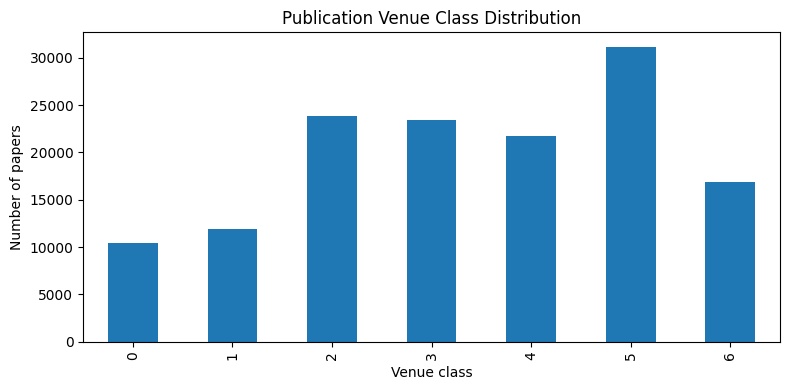

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

label_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure(figsize=(8, 4))
label_counts.plot(kind="bar")
plt.title("Publication Venue Class Distribution")
plt.xlabel("Venue class")
plt.ylabel("Number of papers")
plt.tight_layout()
plt.show()

### Loading Precomputed SciBert Embeddings

In this section we load the precomputed SciBert Embeddings for:
1. training papers
2. validation papers
3. test papers
These embeddings we generated beforehand and stored as NumPy arrays for faster experimentation.

SciBert is a transformer model pretrained specifically on scientific literature.

Compared to traditional TF-IDF features, SciBert embeddings can better capture semantic meaning, contextual relationships, scientific terminology and domain-specific language patterns.

This allows the model to learn richer represantations of research papers.

### Embedding Structure
Each row of the embedding matrices corresponds to one paper.

The shape verify that:
1. every paper has an embedding vector,
2. train / validation / test alignment is correct,
3. the feature dimensions are consistent across datasets

In [8]:
import numpy as np

X_train_scibert = np.load(
    "/kaggle/input/datasets/giorgosboufis/scibert-embeddings/X_train_scibert.npy"
)

X_val_scibert = np.load(
    "/kaggle/input/datasets/giorgosboufis/scibert-embeddings/X_val_scibert.npy"
)

X_test_scibert = np.load(
    "/kaggle/input/datasets/giorgosboufis/scibert-embeddings/X_test_scibert.npy"
)

print(X_train_scibert.shape)
print(X_val_scibert.shape)
print(X_test_scibert.shape)

(139428, 768)
(34858, 768)
(43650, 768)


# Loading the SciBERT Model

This section loads the pretrained **SciBERT** model and its corresponding tokenizer.

SciBERT is specifically pretrained on scientific literature, making it well-suited for understanding the terminology and writing style of research papers.

The model is configured for a multi-class classification task by setting the number of output classes equal to the number of publication venues.

Finally, the model is moved to the selected device (GPU or CPU) to enable efficient training and inference.

In [9]:
# # Load SciBERT
# model_name = "allenai/scibert_scivocab_uncased"

# tokenizer = AutoTokenizer.from_pretrained(model_name)

# scibert_model = AutoModelForSequenceClassification.from_pretrained(
#     model_name,
#     num_labels=num_labels
# )

# scibert_model.config.pad_token_id = tokenizer.pad_token_id

# scibert_model.to(device)

# print("SciBERT loaded successfully.")

# Preparing the Data for SciBERT

This section converts the training, validation, and test datasets into the Hugging Face `Dataset` format required for transformer models.

The abstracts are tokenized using the SciBERT tokenizer, which converts raw text into numerical tokens that the model can process.

During tokenization:
- sequences are padded to a fixed length,
- long abstracts are truncated,
- the maximum sequence length is set to 256 tokens.

After tokenization, the original text column is removed and the datasets are converted to PyTorch format, making them ready for efficient training and inference with SciBERT.

In [10]:
# # Convert pandas dataframes to Hugging Face datasets
# train_hf = Dataset.from_pandas(
#     df_train_final[["abstract", "label"]].reset_index(drop=True)
# )

# val_hf = Dataset.from_pandas(
#     df_val_final[["abstract", "label"]].reset_index(drop=True)
# )

# test_hf = Dataset.from_pandas(
#     test_data[["abstract"]].reset_index(drop=True)
# )

# def tokenize_function(batch):
#     return tokenizer(
#         batch["abstract"],
#         padding="max_length",
#         truncation=True,
#         max_length=256
#     )

# train_hf = train_hf.map(tokenize_function, batched=True)
# val_hf = val_hf.map(tokenize_function, batched=True)
# test_hf = test_hf.map(tokenize_function, batched=True)

# train_hf = train_hf.remove_columns(["abstract"])
# val_hf = val_hf.remove_columns(["abstract"])
# test_hf = test_hf.remove_columns(["abstract"])

# train_hf.set_format("torch")
# val_hf.set_format("torch")
# test_hf.set_format("torch")

# print(train_hf)

# Applying LoRA Fine-Tuning

This section applies **LoRA (Low-Rank Adaptation)** to the SciBERT model.

Instead of updating all model parameters, LoRA inserts small trainable adapters into selected transformer layers while keeping the original pretrained weights frozen.

The adapters are applied to the attention **query** and **value** modules, allowing the model to adapt efficiently to the publication venue classification task.

Using LoRA significantly reduces the number of trainable parameters, lowering memory usage and training time while maintaining strong performance.

In [11]:
# # Add LoRA adapters
# lora_config = LoraConfig(
#     task_type=TaskType.SEQ_CLS,
#     r=16,
#     lora_alpha=32,
#     lora_dropout=0.1,
#     bias="none",
#     target_modules=["query", "value"]
# )

# scibert_model = get_peft_model(scibert_model, lora_config)

# scibert_model.print_trainable_parameters()

# Evaluation Metrics

This function computes the evaluation metrics used to assess the SciBERT model.

The model outputs logits, which are converted into class probabilities using the softmax function. The predicted class is then obtained by selecting the highest probability.

The following metrics are reported:

- **Accuracy:** measures the proportion of correctly classified papers.
- **Macro F1-score:** evaluates classification performance by giving equal importance to every class, making it suitable for potentially imbalanced datasets.
- **Log Loss:** measures the quality of the predicted probabilities and serves as the primary optimization metric for this challenge, with lower values indicating better performance.

In [12]:
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred

#     probs = torch.softmax(torch.tensor(logits), dim=1).cpu().numpy()
#     preds = np.argmax(probs, axis=1)

#     return {
#         "accuracy": accuracy_score(labels, preds),
#         "macro_f1": f1_score(labels, preds, average="macro"),
#         "log_loss": log_loss(
#             labels,
#             probs,
#             labels=list(range(num_labels))
#         )
#     }

# Hyperparameter Search Space

This section defines the hyperparameter search space for fine-tuning the SciBERT model.

The explored hyperparameters include:

- learning rate,
- batch size,
- weight decay,
- number of training epochs,
- LoRA dropout rate.

Testing different combinations of these parameters allows the model to balance learning efficiency, regularization, and generalization, ultimately identifying configurations that achieve lower validation Log Loss.

In [13]:
# import random

# search_space = {
#     "learning_rate": [1e-4, 2e-4, 5e-4],
#     "batch_size": [8, 16],
#     "weight_decay": [0.001, 0.01],
#     "epochs": [2, 3],
#     "lora_dropout": [0.1, 0.2, 0.3]
# }

# Hyperparameter Search Initialization

This section initializes the hyperparameter search procedure.

A fixed number of trials is defined, and variables are created to store:

* the results of each experiment,
* the best validation Log Loss achieved,
* the corresponding hyperparameter configuration.

During the search, every candidate configuration is evaluated, and the one with the lowest validation Log Loss is selected for the final model.


In [14]:
# N_TRIALS = 5

# results = []

# best_score = float("inf")
# best_config = None

# Random Hyperparameter Sampling

This section performs one iteration of the random hyperparameter search.

For each trial, a configuration is generated by randomly selecting values from the predefined search space. The selected configuration is then printed and used to train and evaluate the model.

Random search explores different combinations of hyperparameters efficiently without testing every possible combination, often finding strong configurations with fewer experiments than exhaustive grid search.


In [15]:
# for trial in range(N_TRIALS):

#     print("\n" + "=" * 60)
#     print(f"TRIAL {trial + 1}/{N_TRIALS}")

#     config = {
#         key: random.choice(values)
#         for key, values in search_space.items()
#     }

#     print("Configuration:", config)

# Initializing the SciBERT Model with LoRA

For each hyperparameter trial, a new SciBERT classification model is initialized and configured for the publication venue prediction task.

LoRA adapters are then attached to the transformer, with the dropout rate determined by the current hyperparameter configuration. The adapters are applied to the attention **query** and **value** modules, allowing efficient fine-tuning while keeping most pretrained parameters fixed.

Finally, the model is moved to the selected device (GPU or CPU) for training and evaluation.


In [16]:
# scibert_model = AutoModelForSequenceClassification.from_pretrained(
#     model_name,
#     num_labels=num_labels
# )

# scibert_model = get_peft_model(
#     scibert_model,
#     LoraConfig(
#         task_type=TaskType.SEQ_CLS,
#         r=8,
#         lora_alpha=32,
#         target_modules=["query", "value"],
#         lora_dropout=config["lora_dropout"],
#         bias="none"
#     )
# )

# scibert_model.to(device)

# Configuring the Training Process

This section defines the training configuration for the current SciBERT trial using the Hugging Face `TrainingArguments` API.

The selected hyperparameters include:

* learning rate,
* batch size,
* number of training epochs,
* weight decay.

The model is evaluated and saved after each epoch, while the checkpoint with the lowest validation **Log Loss** is automatically restored at the end of training.

Mixed-precision (`fp16`) training is enabled when a GPU is available to improve computational efficiency and reduce memory usage.


In [17]:
# training_args = TrainingArguments(

#     output_dir=f"trial_{trial}",

#     seed=SEED,

#     eval_strategy="epoch",

#     save_strategy="epoch",

#     learning_rate=config["learning_rate"],

#     per_device_train_batch_size=config["batch_size"],

#     per_device_eval_batch_size=32,

#     num_train_epochs=config["epochs"],

#     weight_decay=config["weight_decay"],

#     logging_steps=100,

#     load_best_model_at_end=True,

#     metric_for_best_model="log_loss",

#     greater_is_better=False,

#     save_total_limit=1,

#     report_to="none",

#     fp16=torch.cuda.is_available(),

#     remove_unused_columns=False
# )

# Initializing the Trainer

This section creates the Hugging Face `Trainer`, which manages the complete fine-tuning workflow for SciBERT.

The trainer is configured with:

* the SciBERT model,
* the training arguments,
* the training dataset,
* the validation dataset,
* the evaluation metrics.

It automates the training and evaluation process, ensuring that model performance is monitored on the validation set throughout fine-tuning.


In [18]:
# trainer = Trainer(
#     model=scibert_model,
#     args=training_args,
#     train_dataset=train_hf,
#     eval_dataset=val_hf,
#     compute_metrics=compute_metrics
# )

# Fine-Tuning the SciBERT Model

This step starts the fine-tuning process for the current SciBERT configuration.

During training, the model learns from the training dataset while its performance is evaluated on the validation set after each epoch. The validation metrics are used to monitor generalization and identify the best-performing model checkpoint.

The resulting model is then used for comparison with other configurations in the hyperparameter search.


In [19]:
# trainer.train()

### Loading the Citation Graph

We load the citation graph from `edgelist.txt`.

The graph describes relationships between papers using:
1. source nodes
2. target nodes
Each row represents a connection between two papers.

The graph is stored as an edge list:

```text
source_paper_id, target_paper_id
where source represents the citing paper and target represents the referenced paper

In [20]:
EDGE_PATH = "/kaggle/input/datasets/giorgosboufis/publication-venue-prediction-challenge/edgelist.txt"

edges = pd.read_csv(
    EDGE_PATH,
    sep=",",
    header=None,
    names=["source", "target"]
)

edges["source"] = edges["source"].astype(int)
edges["target"] = edges["target"].astype(int)

### Degree Distribution Analysis

The degree distribution of the citation network is highly skewed. Most papers have relatively few connections, while a small number of papers act as hubs with thousands of citations.
This behavior is typical of real-world citation networks and suggests the presence of important structural information that can be exploited by graph-based methods. The logarithmic scale on the y-axis highlights the long-tail nature of the distribution and reveals the existence of highly connected nodes.
These observations motivated the use of graph-derived features susch as DeepWalk embeddings,degree statistics, PageRank scores, and neighborhood-based label features in the final classification pipeline.

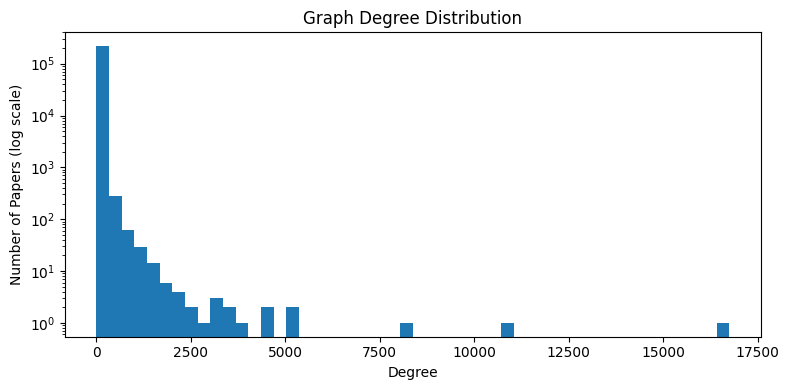

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

degree_counts = pd.concat([
    edges["source"],
    edges["target"]
]).value_counts()

plt.figure(figsize=(8, 4))

plt.hist(
    degree_counts.values,
    bins=50,
    log=True
)

plt.title("Graph Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of Papers (log scale)")

plt.tight_layout()
plt.show()

### Building the Graph Structure 

We convert the raw edge list into a directed graph using NetworkX.

The resulting graph represents the citation relationships between papers.

If Paper A cites Paper B this does not mean that Paper B cites Paper A.

Because of this,  we use a `DiGraph` instead of an undirected graph. This preserves the true structure of the citation network.

As we can see from the results the graph containts 217936 nodes and 1773693 edges.

In [22]:
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    create_using=nx.DiGraph()
)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 217936
Edges: 1773693


# Creating an Undirected Graph

This section converts the citation graph from a directed to an undirected representation.

An undirected graph is useful for algorithms and graph statistics that rely on mutual connectivity rather than citation direction. It allows neighboring papers to be treated as connected regardless of which paper cites the other.

Finally, the number of nodes and edges is printed to verify that the graph has been constructed correctly.


In [23]:
G_undirected = G.to_undirected()

print("Nodes:", G_undirected.number_of_nodes())
print("Edges:", G_undirected.number_of_edges())

Nodes: 217936
Edges: 1767049


### Random Walk Generation for DeepWalk

We want to capture structural relationships between papers in the citation graph, we generate random walks on the graph. A random walk starts from a node (paper) and repeatedly moves to a randomly selected neighboring node. These walks act similarly to sentences in NLP, where node correspond to words. The generated walks are later used to train a Word2Vec model in order to learn low-dimensional graph embeddings for each paper.

In [24]:
import random
from tqdm import tqdm

# Generate a random walk starting from a given node
def random_walk(graph, start_node, walk_length):

    # Initialize walk with the starting node
    walk = [str(start_node)]
    
    current_node = start_node

    # Continue the walk until the desired length is reached
    for _ in range(walk_length - 1):

        # Get neighboring nodes of the current node
        neighbors = list(graph.neighbors(current_node))

        # Stop if the node has no neighbors
        if len(neighbors) == 0:
            break

        # Randomly select the next node
        current_node = random.choice(neighbors)

        # Append selected node to the walk
        walk.append(str(current_node))

    return walk

### Random Walks Corpus Construction

Multiple random walks are generated for every node in the citation graph in order to capture both local and global graph structure.

For each iteration:
1. the node order is shuffled to increase randomness
2. a random walk is generated from every node
3. the resulting walks are stored in a corpus

This corpus is later used to train Word2Vec model and produce DeepWalk graph embeddings

In [25]:
# Length of each random walk
walk_length = 20

# Number of walks generated per node
walks_per_node = 3

# Get all graph nodes
nodes = list(G_undirected.nodes())

# Store all graph nodes
walks = []

# Generate multiple walks for each node
for _ in range(walks_per_node):

    # Shuffle node order to increase randomness
    random.shuffle(nodes)

    # Generate a random walk starting from every node
    for node in tqdm(nodes):
        walks.append(random_walk(G_undirected, node, walk_length))

print("Number of walks:", len(walks))
print("Example walk:", walks[0])

100%|██████████| 217936/217936 [00:27<00:00, 8028.51it/s]

Number of walks: 653808
Example walk: ['18579', '18578', '2142', '209060', '13813', '85322', '2142', '9672', '9575', '63211', '182388', '23804', '2676', '48709', '411', '132710', '2155', '92302', '490', '38981']


### Training the DeepWalk Embedding Model

Here we train a Word2Vec model on the random walks generated from the citation graph.

The random walks act like sentences, while the paper nodes act like words.

The goal is to learn vector representations (embeddings) for each paper based on its graph neighborhood structure.

Papers that frequently appear in similar graph context often:
1. belong to related research communities,
2. discuss similar topics,
3. appear in similar publication venues.

DeepWalk captures these structural relationships and converts them into dense numerical vectors that can lately be combined with:
1. SciBERT embeddings,
2. author features,
3. year features.

---

`vector_size=128` : Each paper is represented by a 128-dimensional embedding vector.

`window=5` : Defines how many neighboring nodes are considered as context during training.

`sg=1` : Uses the Skip-Gram architecture, which is commonly used in DeepWalk.

`epochs=5` : The model trains over the random walks multiple times to improve the learned representations.

`seed=SEED` : Ensures reproducibility of the embedding generation process.

In [26]:
from gensim.models import Word2Vec

deepwalk_model = Word2Vec(
    sentences=walks,
    vector_size=128,
    window=5,
    min_count=1,
    sg=1,
    workers=4,
    epochs=5,
    seed=SEED
)

### Converting DeepWalk Embeddings into Featue Matrices

This function transforms the learned DeepWalk node embeddings into a matrix format that can be used by machine learning models.

For each paper ID;
1. the function searches for its corresponding graph embedding,
2. retrives the embedding vector from the trained DeepWalk model,
3. stores it in the final feature matrix.

The Word2Vec model stores embeddings internally using node keys.

However, machine learning models require a structured numerical matrix where:
- each row corresponds to one paper,
- each column corresponds to one embedding dimension.

Also, some paper IDs may not exist inside the learned embedding vocabulary.

In those cases the embedding remains a zero vector.

This prevents indexing errors, dimension mismatches and pipeline failures during feature concatenation.

The resulting matrix has shape (number_of_papers, embedding_dimension)

In [27]:
def get_deepwalk_matrix(ids, model, dim=128):
    X = np.zeros((len(ids), dim), dtype=np.float32)

    for i, node_id in enumerate(ids):
        key = str(node_id)

        if key in model.wv:
            X[i] = model.wv[key]

    
    return X

### Generating DeepWalk Feature Matrices

In this step we generate the final DeepWalk feature matrices for:
1. training set,
2. validation set,
3. test set.

Using the paper IDs, we retrieve the corresponding graph embeddings from the trained DeepWalk model.

The DeepWalk model learns embddings for graph nodes, but the machine learning pipeline requires:
- one feature vector per paper,
- aligned with the train/validation/test datasets.

This step converts the learned graph representations into structured matrices that can later be combined with SciBERT embeddings, author features and year information.

### Dataset Alignment:

Each row in the resulting matrices correspond to:
1. the same paper position
2. as the matching dataset rows.

Correct alignment is critical because embeddings, labels and metadata must refer to the exact same paper instance during training and evaluation.

In [28]:
train_ids = df_train_final["id"].values
val_ids = df_val_final["id"].values
test_ids = df_test["id"].values

X_train_deepwalk = get_deepwalk_matrix(train_ids, deepwalk_model, dim=128)
X_val_deepwalk = get_deepwalk_matrix(val_ids, deepwalk_model, dim=128)
X_test_deepwalk = get_deepwalk_matrix(test_ids, deepwalk_model, dim=128)

print(X_train_deepwalk.shape)
print(X_val_deepwalk.shape)
print(X_test_deepwalk.shape)

(139428, 128)
(34858, 128)
(43650, 128)


### Extract Graph Statistics Features

We compute additional structural features from the citation graph.

Instead of learning embeddings, we directly measure important graph properties for each paper node.

The extracted features are:
1. in-degree,
2. out-degree,
3. total degree,
4. PageRank,
5. clustering coefficient

These statistics provide complementary structural information about each paper's role inside the citation network.

Papers occupy different positions in the graph.

Some papers are highly cited, connect multiple research communities, belong to dense local neighborhoods and act as influential references.

These structural patterns can correlate with publication venues and research domains.

Graph statistics help the model capture information explicitly.

### In-Degree:

Measures how many incoming citations a paper receives.

### Out-Degree:

Measures how many papers a node cites.

### Total Degree:
Represents the total number of graph connections for a paper. This gives a general measure of graph activity.


### PageRank:

PageRank estimates the importance of a node inside the citation network. A paper connected to other important papers receives higher score. This helps to capture global graph influence.

### Clustering Coefficient:

Measures how densely connected a paper's neighboorhood is.

High clustering may indicate:
1. tightly connected research communities,
2. specialized subfields,
3. local citation patterns.


The graph features are normalized using `StandardScaler`, because the feature ranges are very different:
1. degrees may be large integers,
2. PageRank values are small decimals,
3. clustering coefficients range between 0 and 1.

Without scaling large-value features could dominate training, optimization may become unstable and some models may perform worse.

In [29]:
# Graph statistics features

import networkx as nx
import numpy as np
from sklearn.preprocessing import StandardScaler

G_undirected = G.to_undirected()

in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
total_degree = dict(G_undirected.degree())

pagerank = nx.pagerank(G, alpha=0.85)

clustering = nx.clustering(G_undirected)

def get_graph_stats(ids):
    X = np.zeros((len(ids), 5), dtype=np.float32)

    for i, node_id in enumerate(ids):
        node_id = int(node_id)

        X[i, 0] = in_degree.get(node_id, 0)
        X[i, 1] = out_degree.get(node_id, 0)
        X[i, 2] = total_degree.get(node_id, 0)
        X[i, 3] = pagerank.get(node_id, 0.0)
        X[i, 4] = clustering.get(node_id, 0.0)

    return X

X_train_graph_stats = get_graph_stats(train_ids)
X_val_graph_stats = get_graph_stats(val_ids)
X_test_graph_stats = get_graph_stats(test_ids)

graph_stats_scaler = StandardScaler()

X_train_graph_stats = graph_stats_scaler.fit_transform(X_train_graph_stats)
X_val_graph_stats = graph_stats_scaler.transform(X_val_graph_stats)
X_test_graph_stats = graph_stats_scaler.transform(X_test_graph_stats)

print(X_train_graph_stats.shape)
print(X_val_graph_stats.shape)
print(X_test_graph_stats.shape)

(139428, 5)
(34858, 5)
(43650, 5)


### Loading Authors Information

We load the author metadata for the scietific papers. The author information provides additional context beyond the abstract text and citation graph.

The dataset contains paper identifiers, and associated author information.

Each row links a paper to its author, allowing us to later transform this metadata into numerical features.

In [30]:
AUTHOR_PATH = "/kaggle/input/datasets/giorgosboufis/publication-venue-prediction-challenge/authors.txt"

df_authors = pd.read_csv(
    AUTHOR_PATH,
    sep="\t",
    header=None
)

print(df_authors.shape)
df_authors.head()

(217936, 1)


,0
0,"0||Stavros D. Nikolopoulos,Leonidas Palios"
1,"1||Ka Wong Chong,Stavros D. Nikolopoulos,Leoni..."
2,"2||Stavros D. Nikolopoulos,Leonidas Palios"
3,"3||M Koyuturk,A Grama,N Ramakrishnan"
4,"4||Muhammet Mustafa Ozdal,Cevdet Aykanat"


### Parsing and Cleaning Author Data

The raw author file is stored in a combined text format where the paper ID and the author list are contained in the same column separated by `||`.

In this step we split the raw text into structured columns.

The preprocessing pipeline:
1. separates paper IDs from author names,
2. converts IDs into integers,
3. handles missing author values,
4. keeps only the useful columns for later processing.

By organizing the author information into separate columns, we prepare it for text vectorization, dimensionality reduction and feature fusion with the rest of the pipeline.

In [31]:
df_authors.columns = ["raw"]

split_cols = df_authors["raw"].str.split(r"\|\|", expand=True)

df_authors["id"] = split_cols[0].astype(int)
df_authors["authors"] = split_cols[1].fillna("")

df_authors = df_authors[["id", "authors"]]

print(df_authors.shape)
df_authors.head()

(217936, 2)


,id,authors
0,0,"Stavros D. Nikolopoulos,Leonidas Palios"
1,1,"Ka Wong Chong,Stavros D. Nikolopoulos,Leonidas..."
2,2,"Stavros D. Nikolopoulos,Leonidas Palios"
3,3,"M Koyuturk,A Grama,N Ramakrishnan"
4,4,"Muhammet Mustafa Ozdal,Cevdet Aykanat"


### Cleaning Author Names

The cleaning function converts all text to lowercase, replaces separators such as commas and semicolons, removes unnecessary special characters, preserves useful symbols such as initials, dots, hyphens, and removes repeated spaces.

In [32]:
import re

def clean_authors(s):
    if pd.isna(s):
        return ""

    s = str(s).lower()

    # split author separators
    s = s.replace(",", " ")
    s = s.replace(";", " ")

    # remove weird chars but keep initials/dots/hyphens
    s = re.sub(r"[^a-z0-9.\-\s]", " ", s)

    # normalize multiple spaces
    s = re.sub(r"\s+", " ", s).strip()

    return s

df_authors["authors_clean"] = df_authors["authors"].apply(clean_authors)

df_authors.head()

,id,authors,authors_clean
0,0,"Stavros D. Nikolopoulos,Leonidas Palios",stavros d. nikolopoulos leonidas palios
1,1,"Ka Wong Chong,Stavros D. Nikolopoulos,Leonidas...",ka wong chong stavros d. nikolopoulos leonidas...
2,2,"Stavros D. Nikolopoulos,Leonidas Palios",stavros d. nikolopoulos leonidas palios
3,3,"M Koyuturk,A Grama,N Ramakrishnan",m koyuturk a grama n ramakrishnan
4,4,"Muhammet Mustafa Ozdal,Cevdet Aykanat",muhammet mustafa ozdal cevdet aykanat


### Building Author Datasets for train/validation and test sets

In this step we align the cleaned author information with training, validation and test set. 

We perform the merge using the paper `id` so that each paper receives its corresponding author metadata.

In [33]:
train_authors = df_train_final[["id"]].merge(
    df_authors[["id", "authors_clean"]],
    on="id",
    how="left"
)

val_authors = df_val_final[["id"]].merge(
    df_authors[["id", "authors_clean"]],
    on="id",
    how="left"
)

test_authors = df_test[["id"]].merge(
    df_authors[["id", "authors_clean"]],
    on="id",
    how="left"
)

train_authors["authors_clean"] = train_authors["authors_clean"].fillna("")
val_authors["authors_clean"] = val_authors["authors_clean"].fillna("")
test_authors["authors_clean"] = test_authors["authors_clean"].fillna("")

print(train_authors.shape)
print(val_authors.shape)
print(test_authors.shape)

(139428, 2)
(34858, 2)
(43650, 2)


### TF-IDF Feature Extraction for Author Information

In this section we transform the cleaned author text into numerical feature vectors using TF-IDF. 

TF-IDF helps capture patterns by measuring how informative each author-related token is across the dataset.

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

author_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 3),
    min_df=2,
    max_features=30000,
    sublinear_tf=True
)

X_train_authors = author_vectorizer.fit_transform(train_authors["authors_clean"])
X_val_authors = author_vectorizer.transform(val_authors["authors_clean"])
X_test_authors = author_vectorizer.transform(test_authors["authors_clean"])

print(X_train_authors.shape)
print(X_val_authors.shape)
print(X_test_authors.shape)

(139428, 30000)
(34858, 30000)
(43650, 30000)


### Dimensionality Reduction for Author Features

The TF-IDF author representation is extremely high-dimensional and sparse.

To create a more compact and efficient representation, we apply Truncated SVD. This reduces the author feature space into dense low-dimensional embeddings.

TF-IDF matrices often contains thousands of sparse features, many correlated dimensionsm, and significant memory usage. Direclty using these features can increase training time, make optimization harder and increase overfitting risk, whereas Truncated SVD compresses the information while preserving the most important underlying patterns.

In [35]:
from sklearn.decomposition import TruncatedSVD

svd_authors = TruncatedSVD(
    n_components=128,
    random_state=SEED
)

X_train_authors_svd = svd_authors.fit_transform(
    X_train_authors
).astype(np.float32)

X_val_authors_svd = svd_authors.transform(
    X_val_authors
).astype(np.float32)

X_test_authors_svd = svd_authors.transform(
    X_test_authors
).astype(np.float32)

print(X_train_authors_svd.shape)
print(X_val_authors_svd.shape)
print(X_test_authors_svd.shape)

(139428, 128)
(34858, 128)
(43650, 128)


### Loading Publication Year Information

We load the publication year metadata for the papers.

The year information provides temporal context that may help distinguish publication venues.

The year file contains raw text entries associated with paper identifiers. We first load the data in its raw format before parsing and preprocessing it into structured numerical features.

In [36]:
YEAR_PATH = "/kaggle/input/datasets/giorgosboufis/publication-venue-prediction-challenge/years.txt"

df_years = pd.read_csv(
    YEAR_PATH,
    sep="\t",
    header=None,
    names=["raw"]
)

print(df_years.shape)
df_years.head()

(217936, 1)


,raw
0,"0,2007"
1,"1,2004"
2,"2,2004"
3,"3,2005"
4,"4,2004"


### Parsing Publication Year Data

The publication year file is initially loaded as raw text. 

Each row contains:
1. a paper ID,
2. its publication year, 

stored in a comma-separated format.

The preprocessing pipeline is:
1. splits each row into separate fields,
2. extracts the paper identifier,
3. extracts the publication year,
4. keeps only the relevant columns.

In [37]:
split_cols = df_years["raw"].str.split(",", expand=True)

df_years["id"] = split_cols[0].astype(int)
df_years["year"] = split_cols[1].astype(int)

df_years = df_years[["id", "year"]]

print(df_years.shape)
df_years.head()

(217936, 2)


,id,year
0,0,2007
1,1,2004
2,2,2004
3,3,2005
4,4,2004


### Temporal Analysis of Publications

Figure X shows the distribution of publication years in the dataset. The number of publications increases steadily over time, with a significant concentration of papers in the most recent years (2021–2024).

This trend reflects the rapid growth of scientific output and indicates that the dataset is dominated by modern research publications. The temporal distribution suggests that publication year may contain predictive information, since research topics, venues, and publication patterns evolve over time.

To exploit this information, the publication year was incorporated as a numerical feature in the final classification pipeline after appropriate preprocessing and normalization.

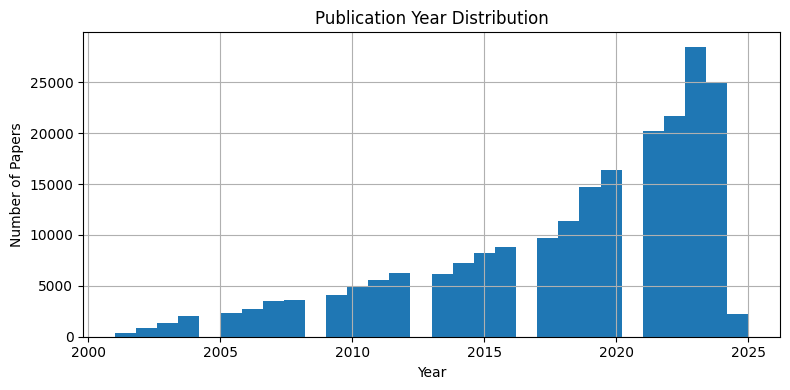

In [38]:
plt.figure(figsize=(8,4))

df_years["year"].hist(bins=30)

plt.title("Publication Year Distribution")
plt.xlabel("Year")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()

### Aligning Year Information with the Dataset splits

In this step we attach the publication year information to the training, validation and test set.

The merge is performed using the paper `id` so that each paper receives its corresponding publication year.

Before using publication year as features, we must ensure that every paper in each split is matched with its correct year information.

This creates consistent dataset where:
1. paper identifiers,
2. publication years,
3. labels,
4. embeddings,
5. graph features

all refer to the same paper.

In [39]:
train_years = df_train_final[["id"]].merge(
    df_years,
    on="id",
    how="left"
)

val_years = df_val_final[["id"]].merge(
    df_years,
    on="id",
    how="left"
)

test_years = df_test[["id"]].merge(
    df_years,
    on="id",
    how="left"
)

print(train_years.shape)
print(val_years.shape)
print(test_years.shape)

train_years.head()

(139428, 2)
(34858, 2)
(43650, 2)


,id,year
0,178847,2022
1,48320,2004
2,182414,2010
3,20873,2023
4,142945,2010


### Handling missing Publication Years

Some papers may not contain publication year information.

Before using the year feature, we replace missing values with the median publication year computed from the training set.

In [40]:
median_year = train_years["year"].median()

train_years["year"] = train_years["year"].fillna(median_year)
val_years["year"] = val_years["year"].fillna(median_year)
test_years["year"] = test_years["year"].fillna(median_year)

### Scaling the Publication Year Feature

The publication year is a numerical feature and must be standarized before being combined with the rest of the feature set.

We use `StandardScaler` to normalize the year values.

The publication year has a much larger numerical range than many other features.

If left unscaled, the year feature could have a disproportionate influence during model training.

In [41]:
from sklearn.preprocessing import StandardScaler

year_scaler = StandardScaler()

X_train_year = year_scaler.fit_transform(
    train_years[["year"]]
).astype(np.float32)

X_val_year = year_scaler.transform(
    val_years[["year"]]
).astype(np.float32)

X_test_year = year_scaler.transform(
    test_years[["year"]]
).astype(np.float32)

print(X_train_year.shape)
print(X_val_year.shape)
print(X_test_year.shape)

(139428, 1)
(34858, 1)
(43650, 1)


### Neighbor Label Distribution Features

In this section we create graph-based features using the labels of neighboring papers in the citation network.

For each paper, we examine its connected neighbors and count how many belong to each publication venue.

The result is a probability-like distribution over all venue classes.

Scientific papers that are connected in the citation graph often belong to:
1. similar research areas,
2. related scientific communities,
3. the same conferences or journals.

Therefore, the labels of neighboring papers can provide valuable information about the likely venue of a paper.

Firstly, we create a label lookup table, a dictionary is created that maps paper_id -> publication_label using only the training set labels. This allows the algorithm to quickly retrieve the known venue of any training paper. 

Then, we build the graph neighborhoods. For every edge in the graph, neighboring papers are stored.

The graph is treated as undirected for this feature so that all connected papers can contribute information. This creates a neighborhood for every node containing its directly connected papers.

Finally, we count neighbor labels. For each paper:
1. visit all neighboring nodes,
2. check whether the neighbor belongs to the training set,
3. retrieve its venue label,
4. increment the corresponding class counter.








In [42]:
from collections import defaultdict
import numpy as np
from sklearn.preprocessing import normalize

num_classes = len(np.unique(y_train))

train_label_by_id = {
    int(pid): int(label)
    for pid, label in zip(train_ids, y_train)
}

neighbors = defaultdict(set)

for _,row in edges.iterrows():
    u = int(row["source"])
    v = int(row["target"])

    neighbors[u].add(v)
    neighbors[v].add(u)

def neighbor_label_features(ids):
    X = np.zeros((len(ids), num_classes), dtype=np.float32)

    for i, pid in enumerate(ids):
        pid = int(pid)

        for nb in neighbors.get(pid, []):
            if nb in train_label_by_id:
                label = train_label_by_id[nb]
                X[i, label] += 1

    X = normalize(X, norm="l1", axis=1)

    return X

X_train_neighbor = neighbor_label_features(train_ids)
X_val_neighbor = neighbor_label_features(val_ids)
X_test_neighbor = neighbor_label_features(test_ids)

print(X_train_neighbor.shape)
print(X_val_neighbor.shape)
print(X_test_neighbor.shape)

(139428, 7)
(34858, 7)
(43650, 7)


### Weighted Neighbor Label Features

This feature extends the neighbor-label approach by distinguish between:
1. outgoing citations (papers this paper cities)
2. ingoing citations (papers citing this paper)

For each paper, we count venue labels of neighboring training papers and assign different weights.

Incoming citations receive higher importance because papers citing a work are often more closely related to its research area and publication year.

The resulting class counts are L1-normalized, producing a probability-like distribution over publication venues.

This feature captures both local graph structure and citation direction information while avoiding data leakage by using only training labels.

In [43]:
def weighted_neighbor_label_features(ids):
    X = np.zeros((len(ids), num_classes), dtype=np.float32)

    for i, pid in enumerate(ids):
        pid = int(pid)

        # papers this paper cites
        out_nbs = set(
            edges.loc[
                edges["source"] == pid,
                "target"
            ].astype(int)
        )

        # papers citing this paper
        in_nbs = set(
            edges.loc[
                edges["target"] == pid,
                "source"
            ].astype(int)
        )

        for nb in out_nbs:
            if nb in train_label_by_id:
                X[i, train_label_by_id[nb]] += 0.7

        for nb in in_nbs:
            if nb in train_label_by_id:
                X[i, train_label_by_id[nb]] += 1.0

    X = normalize(X, norm="l1", axis=1)

    return X

X_train_neighbor_weighted = weighted_neighbor_label_features(train_ids)
X_val_neighbor_weighted = weighted_neighbor_label_features(val_ids)
X_test_neighbor_weighted = weighted_neighbor_label_features(test_ids)

print(X_train_neighbor_weighted.shape)

(139428, 7)


# Feature Fusion

In this step, all feature sources are combined into a single feature matrix for each paper.

The final representation includes:

- SciBERT embeddings (semantic information)
- DeepWalk embeddings (graph structure)
- Graph statistics (PageRank, degree, clustering)
- Weighted neighbor label distributions
- Author embeddings (TF-IDF + SVD)
- Standardized publication year

By combining textual, graph, author, and temporal information, the model can leverage complementary signals that would not be available from any single feature source alone.

The resulting matrices are used as the final inputs for model training, validation, and test prediction.

In [44]:
X_train_final = np.hstack([
    X_train_scibert,
    X_train_deepwalk,
    X_train_graph_stats,
    X_train_neighbor_weighted,
    X_train_authors_svd,
    X_train_year
])

X_val_final = np.hstack([
    X_val_scibert,
    X_val_deepwalk,
    X_val_graph_stats,
    X_val_neighbor_weighted,
    X_val_authors_svd,
    X_val_year
])

X_test_final = np.hstack([
    X_test_scibert,
    X_test_deepwalk,
    X_test_graph_stats,
    X_test_neighbor_weighted,
    X_test_authors_svd,
    X_test_year
])

print("Train:", X_train_final.shape)
print("Val:", X_val_final.shape)
print("Test:", X_test_final.shape)

Train: (139428, 1037)
Val: (34858, 1037)
Test: (43650, 1037)


# Feature Standardization

Before training the neural network, the combined feature matrix is standardized using `StandardScaler`.

This transforms each feature to have:

- mean = 0
- standard deviation = 1

Standardization prevents features with larger numerical ranges from dominating the learning process and helps the MLP converge more efficiently.

To avoid data leakage, the scaler is fitted only on the training set and then applied to the validation and test sets using the same transformation.

In [45]:
scaler = StandardScaler()

X_train_mlp = scaler.fit_transform(X_train_final).astype(np.float32)
X_val_mlp = scaler.transform(X_val_final).astype(np.float32)
X_test_mlp = scaler.transform(X_test_final).astype(np.float32)

print(X_train_mlp.shape, X_val_mlp.shape, X_test_mlp.shape)

(139428, 1037) (34858, 1037) (43650, 1037)


# Preparing Data for MLP Training

This section prepares the final feature matrices and labels for training a neural network in PyTorch.

The code:

- selects the available device (`cuda` if GPU is available, otherwise CPU),
- converts labels to integer class format,
- wraps features and labels into `TensorDataset` objects,
- creates `DataLoader`s for batch training,
- stores the input dimension and number of output classes.

DataLoaders allow the model to train efficiently in mini-batches instead of processing the full dataset at once.

The training loader uses `shuffle=True` so the model sees the data in a different order each epoch, improving generalization.

The validation loader does not shuffle because validation is only used for evaluation, not learning.

In [46]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import log_loss
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

y_train_mlp = np.asarray(y_train).astype(np.int64)
y_val_mlp = np.asarray(y_val).astype(np.int64)

train_ds = TensorDataset(
    torch.tensor(X_train_mlp),
    torch.tensor(y_train_mlp)
)

val_ds = TensorDataset(
    torch.tensor(X_val_mlp),
    torch.tensor(y_val_mlp)
)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)

num_classes = len(np.unique(y_train_mlp))
input_dim = X_train_mlp.shape[1]

print("Input dim:", input_dim)
print("Classes:", num_classes)

cuda
Input dim: 1037
Classes: 7


# Fusion MLP Architecture

This neural network combines all engineered features into a single classification model.

The architecture consists of:
- two fully connected hidden layers,
- Batch Normalization,
- ReLU activations,
- Dropout regularization,
- a final output layer producing class logits.

Batch Normalization helps stabilize training, while Dropout reduces overfitting by randomly deactivating neurons during training.

The final layer outputs one score for each publication venue class, which is later converted into class probabilities using the softmax function.

In [47]:
class FusionMLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden1=512, hidden2=256, dropout=0.3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# MLP Training Function

This function trains one MLP model using a given hyperparameter configuration.

It:
- builds the `FusionMLP` model,
- uses `CrossEntropyLoss` for multi-class classification,
- optimizes the model with AdamW,
- evaluates performance on the validation set after each epoch,
- tracks the best validation LogLoss,
- applies early stopping when validation performance stops improving.

The best model state is saved and restored at the end, so the returned model is the one with the lowest validation LogLoss, not necessarily the model from the final epoch.

In [48]:
def train_one_mlp(config):
    model = FusionMLP(
        input_dim=input_dim,
        num_classes=num_classes,
        hidden1=config["hidden1"],
        hidden2=config["hidden2"],
        dropout=config["dropout"]
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, config["epochs"] + 1):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_probs_list = []
        val_y_list = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                probs = torch.softmax(logits, dim=1).cpu().numpy()

                val_probs_list.append(probs)
                val_y_list.append(yb.numpy())

        val_probs = np.vstack(val_probs_list)
        val_y_true = np.concatenate(val_y_list)

        val_loss = log_loss(val_y_true, val_probs)

        print(f"Epoch {epoch} | Val LogLoss: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= config["patience"]:
            print("Early stopping")
            break

    model.load_state_dict(best_state)

    return best_val_loss, model

# Hyperparameter Search

This section performs a manual hyperparameter search to identify the best MLP configuration.

A small set of candidate architectures and optimization settings is evaluated using validation LogLoss.

The search explores variations in:
- hidden layer sizes,
- dropout rate,
- learning rate,
- weight decay.

For each configuration, the model is trained and evaluated on the validation set. The configuration achieving the lowest validation LogLoss is selected as the final model.

To reduce training time, early stopping is applied during training.

In [49]:
search_space = [
    {"hidden1": 512, "hidden2": 256, "dropout": 0.40, "lr": 5e-4, "weight_decay": 1e-4},
    {"hidden1": 512, "hidden2": 256, "dropout": 0.35, "lr": 5e-4, "weight_decay": 1e-4},
    {"hidden1": 512, "hidden2": 256, "dropout": 0.30, "lr": 5e-4, "weight_decay": 1e-4},
    {"hidden1": 512, "hidden2": 256, "dropout": 0.40, "lr": 3e-4, "weight_decay": 1e-4},
    {"hidden1": 768, "hidden2": 256, "dropout": 0.35, "lr": 5e-4, "weight_decay": 1e-4},
]

best_score = float("inf")
best_model = None
best_config = None

for i, config in enumerate(search_space, 1):
    config = config.copy()
    config["epochs"] = 8
    config["patience"] = 2

    print(f"\nTrial {i}/{len(search_space)}")
    print(config)

    score, model = train_one_mlp(config)

    print("Val LogLoss:", score)

    if score < best_score:
        best_score = score
        best_model = copy.deepcopy(model)
        best_config = config.copy()

print("\nBest score:", best_score)
print("Best config:", best_config)


Trial 1/5
{'hidden1': 512, 'hidden2': 256, 'dropout': 0.4, 'lr': 0.0005, 'weight_decay': 0.0001, 'epochs': 8, 'patience': 2}
Epoch 1 | Val LogLoss: 0.434445
Epoch 2 | Val LogLoss: 0.422044
Epoch 3 | Val LogLoss: 0.412741
Epoch 4 | Val LogLoss: 0.410703
Epoch 5 | Val LogLoss: 0.409577
Epoch 6 | Val LogLoss: 0.406969
Epoch 7 | Val LogLoss: 0.405333
Epoch 8 | Val LogLoss: 0.407017
Val LogLoss: 0.4053326972522627

Trial 2/5
{'hidden1': 512, 'hidden2': 256, 'dropout': 0.35, 'lr': 0.0005, 'weight_decay': 0.0001, 'epochs': 8, 'patience': 2}
Epoch 1 | Val LogLoss: 0.431638
Epoch 2 | Val LogLoss: 0.420094
Epoch 3 | Val LogLoss: 0.412442
Epoch 4 | Val LogLoss: 0.410653
Epoch 5 | Val LogLoss: 0.407220
Epoch 6 | Val LogLoss: 0.407468
Epoch 7 | Val LogLoss: 0.405462
Epoch 8 | Val LogLoss: 0.410882
Val LogLoss: 0.40546241967661495

Trial 3/5
{'hidden1': 512, 'hidden2': 256, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001, 'epochs': 8, 'patience': 2}
Epoch 1 | Val LogLoss: 0.431843
Epoch 2 | Va

# Saving Model Artifacts

After training, we save the best-performing model and all preprocessing components required for inference.

The saved artifacts include:
- the trained MLP model,
- feature scalers,
- the author TF-IDF vectorizer,
- the author SVD transformation,
- the publication year scaler,
- the best hyperparameter configuration.

Saving these components ensures that future predictions use exactly the same preprocessing and model configuration as during training, enabling reproducible and consistent inference.

In [50]:
import torch
import joblib

torch.save(
    best_model.state_dict(),
    "best_mlp_model.pt"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    author_vectorizer,
    "author_vectorizer.pkl"
)

joblib.dump(
    svd_authors,
    "svd_authors.pkl"
)

joblib.dump(
    year_scaler,
    "year_scaler.pkl"
)

joblib.dump(
    best_config,
    "best_config.pkl"
)

print("All artifacts saved.")

All artifacts saved.


# Final MLP Training

This section retrains the MLP using the best hyperparameter configuration found during the manual search.

The final model is trained for more epochs, with early stopping based on validation LogLoss.

During training, the code tracks:
- training loss,
- validation LogLoss,
- the best model state.

The model state with the lowest validation LogLoss is restored at the end, ensuring that the final model is not overfitted to later epochs.

In [51]:
final_config = best_config.copy()
final_config["epochs"] = 30
final_config["patience"] = 3

final_model = FusionMLP(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden1=final_config["hidden1"],
    hidden2=final_config["hidden2"],
    dropout=final_config["dropout"]
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=final_config["lr"],
    weight_decay=final_config["weight_decay"]
)

best_final_loss = float("inf")
best_final_state = None
bad_epochs = 0

for epoch in range(1, final_config["epochs"] + 1):
    final_model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = final_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_ds)

    final_model.eval()
    val_probs_list = []
    val_y_list = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = final_model(xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()

            val_probs_list.append(probs)
            val_y_list.append(yb.numpy())

    val_probs = np.vstack(val_probs_list)
    val_y_true = np.concatenate(val_y_list)
    val_loss = log_loss(val_y_true, val_probs)

    print(f"Epoch {epoch} | TrainLoss: {train_loss:.6f} | ValLogLoss: {val_loss:.6f}")

    if val_loss < best_final_loss:
        best_final_loss = val_loss
        best_final_state = copy.deepcopy(final_model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= final_config["patience"]:
        print("Early stopping")
        break

final_model.load_state_dict(best_final_state)

print("Best final validation log loss:", best_final_loss)

Epoch 1 | TrainLoss: 0.542750 | ValLogLoss: 0.432823
Epoch 2 | TrainLoss: 0.446224 | ValLogLoss: 0.420552
Epoch 3 | TrainLoss: 0.427314 | ValLogLoss: 0.412690
Epoch 4 | TrainLoss: 0.412776 | ValLogLoss: 0.409958
Epoch 5 | TrainLoss: 0.401699 | ValLogLoss: 0.411087
Epoch 6 | TrainLoss: 0.392118 | ValLogLoss: 0.407973
Epoch 7 | TrainLoss: 0.381647 | ValLogLoss: 0.407596
Epoch 8 | TrainLoss: 0.373904 | ValLogLoss: 0.409354
Epoch 9 | TrainLoss: 0.365734 | ValLogLoss: 0.407920
Epoch 10 | TrainLoss: 0.356674 | ValLogLoss: 0.408145
Early stopping
Best final validation log loss: 0.4075959268002573


# Saving the Final Model

After training is complete, the final MLP model is saved to disk.

The saved file contains the learned network weights corresponding to the best validation performance observed during training.

Saving the model allows it to be:
- reused for inference,
- loaded without retraining,
- used to generate predictions for the test set.

In [52]:
torch.save(final_model.state_dict(), "final_mlp_model.pt")

print("Saved final_mlp_model.pt")

Saved final_mlp_model.pt


# Logistic Regression Baseline

This section trains a Logistic Regression classifier on the combined feature set.

The model uses:
- SciBERT embeddings,
- DeepWalk embeddings,
- graph statistics,
- neighbor-label features,
- author embeddings,
- publication year information.

Logistic Regression serves as a strong baseline for high-dimensional feature spaces and produces calibrated class probabilities.

The model is evaluated using validation LogLoss, allowing direct comparison with the MLP and other candidate models.

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
import numpy as np

clf_lr = LogisticRegression(
    max_iter=3000,
    C=0.03,
    solver="lbfgs",
    n_jobs=-1,
    random_state=SEED
)

clf_lr.fit(X_train_final, y_train)

val_probs_lr = clf_lr.predict_proba(X_val_final)

print("LR Val LogLoss:", log_loss(y_val, val_probs_lr))

LR Val LogLoss: 0.433548379549164


# LightGBM Model

This section trains a LightGBM classifier on the fused feature representation.

LightGBM is a gradient boosting algorithm that builds an ensemble of decision trees, allowing it to capture complex nonlinear relationships between features.

The model is trained using:
- SciBERT embeddings,
- DeepWalk embeddings,
- graph statistics,
- neighbor-label features,
- author embeddings,
- publication year information.

Early stopping is applied using the validation set, preventing unnecessary training once validation performance stops improving.

The final model is evaluated using validation LogLoss, which is used to compare its performance against the other candidate models.

In [54]:
!pip install lightgbm -q

import lightgbm as lgb
from sklearn.metrics import log_loss

clf_lgbm = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(np.unique(y_train)),
    n_estimators=800,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    force_col_wise=True
)

clf_lgbm.fit(
    X_train_final,
    y_train,
    eval_set=[(X_val_final, y_val)],
    eval_metric="multi_logloss",
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50)
    ]
)

val_probs_lgbm = clf_lgbm.predict_proba(X_val_final)

print("LightGBM Val LogLoss:", log_loss(y_val, val_probs_lgbm))

[LightGBM] [Info] Total Bins 264035
[LightGBM] [Info] Number of data points in the train set: 139428, number of used features: 1037
[LightGBM] [Info] Start training from score -2.588652
[LightGBM] [Info] Start training from score -2.458492
[LightGBM] [Info] Start training from score -1.763628
[LightGBM] [Info] Start training from score -1.785881
[LightGBM] [Info] Start training from score -1.858716
[LightGBM] [Info] Start training from score -1.499473
[LightGBM] [Info] Start training from score -2.110945
Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 0.554344
[100]	valid_0's multi_logloss: 0.447539
[150]	valid_0's multi_logloss: 0.423032
[200]	valid_0's multi_logloss: 0.41331
[250]	valid_0's multi_logloss: 0.408378
[300]	valid_0's multi_logloss: 0.405622
[350]	valid_0's multi_logloss: 0.404419
[400]	valid_0's multi_logloss: 0.403826
Early stopping, best iteration is:
[398]	valid_0's multi_logloss: 0.403823


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Val LogLoss: 0.4038226369296715


# Evaluating the Final MLP

After training, the final MLP is evaluated on the validation set.

The model is switched to evaluation mode to disable training-specific operations such as dropout.

For each validation batch:
- the model produces class logits,
- logits are converted into class probabilities using the softmax function,
- probabilities are collected for all validation samples.

The resulting probability matrix is used to compute the validation LogLoss, providing a direct measure of the model's predictive performance and enabling comparison with the other models in the ensemble.

In [55]:
final_model.eval()

val_probs_mlp_list = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)

        logits = final_model(xb)

        probs = torch.softmax(logits, dim=1).cpu().numpy()

        val_probs_mlp_list.append(probs)

val_probs_mlp = np.vstack(val_probs_mlp_list)

print("MLP Val LogLoss:", log_loss(y_val, val_probs_mlp))

MLP Val LogLoss: 0.4075959268002573


# Loading SciBERT Predictions

This section loads the validation and test predictions generated by the fine-tuned SciBERT model.

The saved probability matrices contain the predicted class probabilities for each paper and are used as inputs to the ensemble stage.

Using precomputed predictions avoids retraining SciBERT and allows its outputs to be combined efficiently with the predictions from:
- MLP,
- Logistic Regression,
- LightGBM.

This enables the ensemble to leverage both deep semantic information from SciBERT and the complementary signals captured by the other models.

In [56]:
val_probs_scibert = np.load(
    "/kaggle/input/datasets/giorgosboufis/scibert-outputs/val_probs_scibert.npy"
)

test_probs_scibert = np.load(
    "/kaggle/input/datasets/giorgosboufis/scibert-outputs/test_probs_scibert.npy"
)

# Ensemble Weight Optimization

This section searches for the best combination of model weights for the final ensemble.

The ensemble combines predictions from:
- MLP,
- LightGBM,
- SciBERT,
- Logistic Regression.

For each candidate weight combination, a weighted average of the predicted class probabilities is computed and evaluated using validation LogLoss.

The weight combination achieving the lowest validation LogLoss is selected as the final ensemble configuration.

This approach allows the ensemble to leverage the strengths of multiple models and often produces better performance than any individual model alone.

In [57]:
best_weights = None
best_loss = float("inf")

for w_mlp in np.arange(0.0, 1.01, 0.05):
    for w_lgbm in np.arange(0.0, 1.01 - w_mlp, 0.05):
        for w_scibert in np.arange(0.0, 1.01 - w_mlp - w_lgbm, 0.05):
            w_lr = 1.0 - w_mlp - w_lgbm - w_scibert

            ens_probs = (
                w_mlp * val_probs_mlp +
                w_lgbm * val_probs_lgbm +
                w_scibert * val_probs_scibert +
                w_lr * val_probs_lr
            )

            loss = log_loss(y_val, ens_probs)

            if loss < best_loss:
                best_loss = loss
                best_weights = (w_mlp, w_lgbm, w_scibert, w_lr)

print("Best weights:", best_weights)
print("Best val loss:", best_loss)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: T

Best weights: (np.float64(0.30000000000000004), np.float64(0.55), np.float64(0.15000000000000002), np.float64(-1.1102230246251565e-16))
Best val loss: 0.38380866671066927


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: T

# Reproducibility Setup

This function sets the random seeds for Python, NumPy, and PyTorch.

Using a fixed seed helps ensure that:
- model initialization,
- data shuffling,
- random operations

produce consistent results across different runs.

This improves experiment reproducibility and makes model comparisons more reliable.

In [58]:
import random
import numpy as np
import torch

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Alternative MLP Configuration

This configuration defines the hyperparameters used to train a second MLP model.

Training multiple models with different random seeds or training runs can produce slightly different predictions due to stochastic optimization.

The resulting model can be used as an additional ensemble member, helping improve robustness and reducing prediction variance in the final ensemble.

In [59]:
config_seed2 = {
    "hidden1": 512,
    "hidden2": 256,
    "dropout": 0.4,
    "lr": 5e-4,
    "weight_decay": 1e-4,
    "epochs": 10,
    "patience": 3
}

# Training a Second MLP Model

This section trains a second MLP using a different random seed.

Changing the seed affects:
- weight initialization,
- mini-batch ordering,
- optimization dynamics.

Although the architecture and hyperparameters remain the same, the model may learn slightly different decision boundaries.

These differences can provide complementary predictions, making the model useful as an additional component in the final ensemble.

In [60]:
set_all_seeds(123)
score_seed2, model_seed2 = train_one_mlp(config_seed2)

Epoch 1 | Val LogLoss: 0.435068
Epoch 2 | Val LogLoss: 0.420910
Epoch 3 | Val LogLoss: 0.414161
Epoch 4 | Val LogLoss: 0.411665
Epoch 5 | Val LogLoss: 0.409070
Epoch 6 | Val LogLoss: 0.408321
Epoch 7 | Val LogLoss: 0.407944
Epoch 8 | Val LogLoss: 0.407003
Epoch 9 | Val LogLoss: 0.407241
Epoch 10 | Val LogLoss: 0.408142


# Evaluating the Second MLP

After training, the second MLP is evaluated on the validation set.

The model generates class probabilities for each validation sample using the softmax function.

The resulting probability matrix is used to compute the validation LogLoss, allowing comparison with the first MLP and assessing whether the second training run provides complementary predictions for ensembling.

In [61]:
model_seed2.eval()

val_probs_seed2_list = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model_seed2(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        val_probs_seed2_list.append(probs)

val_probs_seed2 = np.vstack(val_probs_seed2_list)

print("Seed2 MLP Val LogLoss:", log_loss(y_val, val_probs_seed2))

Seed2 MLP Val LogLoss: 0.40700258983823456


# Final Ensemble Optimization

This section builds an ensemble using:

- the average predictions of two MLP models,
- LightGBM,
- SciBERT.

First, the predictions of the two MLP runs are averaged to create a more stable neural-network component.

A grid search is then performed over a range of ensemble weights. For each valid weight combination, the weighted average of the model probabilities is evaluated using validation LogLoss.

The weight combination achieving the lowest validation LogLoss is selected as the final ensemble configuration used for test predictions.

In [62]:
val_probs_mlp_avg = (val_probs_mlp + val_probs_seed2) / 2

best_loss_4 = float("inf")
best_weights_4 = None

for w_mlp in np.arange(0.25, 0.56, 0.025):
    for w_lgbm in np.arange(0.30, 0.61, 0.025):
        for w_scibert in np.arange(0.05, 0.26, 0.025):

            total = w_mlp + w_lgbm + w_scibert

            if abs(total - 1.0) > 1e-9:
                continue

            ens_probs = (
                w_mlp * val_probs_mlp_avg +
                w_lgbm * val_probs_lgbm +
                w_scibert * val_probs_scibert
            )

            loss = log_loss(y_val, ens_probs)

            if loss < best_loss_4:
                best_loss_4 = loss
                best_weights_4 = (
                    w_mlp,
                    w_lgbm,
                    w_scibert
                )

print("Best weights:", best_weights_4)
print("Best val loss:", best_loss_4)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: T

Best weights: (np.float64(0.40000000000000013), np.float64(0.47500000000000014), np.float64(0.12500000000000003))
Best val loss: 0.3825627920785323


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: T

# MLP Probability Prediction Function

This helper function generates class probabilities from a trained MLP model.

The input features are:
- converted to PyTorch tensors,
- moved to the selected device (CPU or GPU),
- passed through the neural network.

The output logits are transformed into probabilities using the softmax function, producing a probability distribution over all publication venue classes.

This function is used during inference and ensembling, where probability predictions are required instead of class labels.

In [63]:
import torch
import numpy as np

def predict_proba_mlp(model, X):
    model.eval()

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():
        logits = model(X_tensor)

        probs = torch.softmax(
            logits,
            dim=1
        ).cpu().numpy()

    return probs

# Generating Final Test Predictions

This section generates the final predictions for the test set.

The prediction pipeline:

- obtains probabilities from both MLP models,
- averages the two MLP predictions,
- generates probabilities from LightGBM,
- loads the precomputed SciBERT probabilities,
- combines all models using the optimized ensemble weights.

The resulting weighted probabilities represent the final prediction for each paper.

These predictions are then formatted into the required submission structure and saved as:

```text
submission_final_ensemble_weighted.csv
```

This file is the final output submitted for evaluation.

In [64]:
test_probs_mlp = predict_proba_mlp(final_model, X_test_mlp)

test_probs_seed2 = predict_proba_mlp(model_seed2, X_test_mlp)

test_probs_mlp_avg = (
    test_probs_mlp + test_probs_seed2
) / 2

test_probs_lgbm = clf_lgbm.predict_proba(X_test_final)

test_probs_scibert = np.load(
    "/kaggle/input/datasets/giorgosboufis/scibert-outputs/test_probs_scibert.npy"
)

w_mlp, w_lgbm, w_scibert = best_weights_4

final_probs = (
    w_mlp * test_probs_mlp_avg +
    w_lgbm * test_probs_lgbm +
    w_scibert * test_probs_scibert
)

submission = pd.DataFrame(final_probs)

submission.insert(0, "paper_id", test_ids)

submission.to_csv(
    "submission_final_ensemble_last_try.csv",
    index=False
)

submission.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,paper_id,0,1,2,3,4,5,6
0,2,0.999432,0.000091,0.000193,0.000057,0.000070,0.000135,0.000021
1,10,0.001059,0.634337,0.191009,0.002526,0.002428,0.168322,0.000320
2,12,0.001341,0.040367,0.006759,0.001601,0.001304,0.948343,0.000285
3,22,0.000385,0.124445,0.008839,0.833934,0.000431,0.031858,0.000108
4,32,0.001846,0.012139,0.019069,0.000211,0.951320,0.014271,0.001144
